In [32]:

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import requests
import json
import os
import sys
import time

from arcgis.gis import GIS
from arcgis.features import FeatureLayer, FeatureLayerCollection
from arcgis.geometry import Geometry

In [ ]:


PPQInternationalSegmentsFeatureLayerCode = "ffc2e851a5fd4ef7a1e2581072b5c46d"

ARCGIS_USERNAME = "CSUguest28"
ARCGIS_PASSWORD = "IEatChildren7!"

gis = GIS("https://www.arcgis.com", username=ARCGIS_USERNAME, password=ARCGIS_PASSWORD)
print(f"Connected to ArcGIS Online as: {gis.users.me.username}")

# Retrieve the feature layer item
ppq_item = gis.content.get(PPQInternationalSegmentsFeatureLayerCode)

print(f"\n=== Item Metadata ===")
print(f"Title: {ppq_item.title}")
print(f"Type: {ppq_item.type}")
print(f"Owner: {ppq_item.owner}")
print(f"URL: {ppq_item.url}")

Connected to ArcGIS Online as: csuguest28

=== Item Metadata ===
Title: PPQ International Segments Feature Layer
Type: Feature Service
Owner: csuguest20
URL: https://services1.arcgis.com/KNdRU5cN6ENqCTjk/arcgis/rest/services/PPQ International Segments Feature Layer/FeatureServer


In [ ]:
print("=== Available Layers ===")
for idx, layer in enumerate(ppq_item.layers):
    count = layer.query(return_count_only=True)
    print(f"  [{idx}] {layer.properties.name}")
    print(f"       Geometry: {layer.properties.geometryType}")
    print(f"       Records: {count:,}")

# Show field information
ppq_layer = ppq_item.layers[0]
print(f"\n=== Fields in '{ppq_layer.properties.name}' ===")
for field in ppq_layer.properties.fields:
    print(f"  {field['name']:30} - {field['type'].replace('esriFieldType', '')}")

=== Available Layers ===
  [0] InternationalSegments
       Geometry: esriGeometryPoint
       Records: 544,082

=== Fields in 'InternationalSegments' ===
  OBJECTID                       - OID
  DEPARTURES_SCHEDULED           - Integer
  DEPARTURES_PERFORMED           - Integer
  PAYLOAD                        - Integer
  SEATS                          - Integer
  PASSENGERS                     - Integer
  FREIGHT                        - Integer
  MAIL                           - Integer
  DISTANCE                       - Integer
  RAMP_TO_RAMP                   - Integer
  AIR_TIME                       - Integer
  UNIQUE_CARRIER                 - String
  AIRLINE_ID                     - String
  UNIQUE_CARRIER_NAME            - String
  UNIQUE_CARRIER_ENTITY          - String
  REGION                         - String
  CARRIER                        - String
  CARRIER_NAME                   - String
  CARRIER_GROUP                  - String
  CARRIER_GROUP_NEW              - Strin

In [ ]:

total_inbound = ppq_layer.query(
    where="DEST_COUNTRY_NAME = 'United States' AND ORIGIN_COUNTRY_NAME <> 'United States'",
    return_count_only=True
)
print(f"Total INBOUND flight records (foreign -> US): {total_inbound:,}")

# Query inbound flights sample
print("\nQuerying 5000 inbound flight records...")
inbound_features = ppq_layer.query(
    where="DEST_COUNTRY_NAME = 'United States' AND ORIGIN_COUNTRY_NAME <> 'United States'",
    out_fields="*",
    result_record_count=5000,
    return_geometry=True
)

# Convert to DataFrame
records = [f.attributes for f in inbound_features.features]
ppq_GeoDataFrame = pd.DataFrame(records)

# Add geometry from features
geometries = [f.geometry for f in inbound_features.features]
ppq_GeoDataFrame['geometry'] = geometries

print(f"\nInbound flights DataFrame shape: {ppq_GeoDataFrame.shape}")
print(f"Date range: {ppq_GeoDataFrame['YEAR_WADS'].min()} to {ppq_GeoDataFrame['YEAR_WADS'].max()}")
print(f"Unique origin countries: {ppq_GeoDataFrame['ORIGIN_COUNTRY_NAME'].nunique()}")
print(f"Unique US entry airports: {ppq_GeoDataFrame['DEST'].nunique()}")
ppq_GeoDataFrame.head()

In [38]:


def query_all_inbound_flights(layer, batch_size=2000):
    """Query all inbound flights to the US with pagination"""
    where_clause = "DEST_COUNTRY_NAME = 'United States' AND ORIGIN_COUNTRY_NAME <> 'United States'"
    
    all_records = []
    offset = 0
    total = layer.query(where=where_clause, return_count_only=True)
    
    print(f"Downloading {total:,} inbound flight records in batches of {batch_size}...")
    
    while offset < total:
        features = layer.query(
            where=where_clause,
            out_fields="*",
            result_record_count=batch_size,
            result_offset=offset,
            return_geometry=True
        )
        
        batch_records = [f.attributes for f in features.features]
        all_records.extend(batch_records)
        
        offset += batch_size
        print(f"  Progress: {min(offset, total):,} / {total:,} ({100*min(offset,total)/total:.1f}%)")
    
    return pd.DataFrame(all_records)

ppq_full_df = query_all_inbound_flights(ppq_layer)
print(f"\nFull inbound dataset shape: {ppq_full_df.shape}")

print("To download all inbound flight data, uncomment the lines above.")

  Progress: 2,000 / 270,753 (0.7%)
  Progress: 4,000 / 270,753 (1.5%)
  Progress: 6,000 / 270,753 (2.2%)
  Progress: 8,000 / 270,753 (3.0%)
  Progress: 10,000 / 270,753 (3.7%)
  Progress: 12,000 / 270,753 (4.4%)
  Progress: 14,000 / 270,753 (5.2%)
  Progress: 16,000 / 270,753 (5.9%)
  Progress: 18,000 / 270,753 (6.6%)
  Progress: 20,000 / 270,753 (7.4%)
  Progress: 22,000 / 270,753 (8.1%)
  Progress: 24,000 / 270,753 (8.9%)
  Progress: 26,000 / 270,753 (9.6%)
  Progress: 28,000 / 270,753 (10.3%)
  Progress: 30,000 / 270,753 (11.1%)
  Progress: 32,000 / 270,753 (11.8%)
  Progress: 34,000 / 270,753 (12.6%)
  Progress: 36,000 / 270,753 (13.3%)
  Progress: 38,000 / 270,753 (14.0%)
  Progress: 40,000 / 270,753 (14.8%)
  Progress: 42,000 / 270,753 (15.5%)
  Progress: 44,000 / 270,753 (16.3%)
  Progress: 46,000 / 270,753 (17.0%)
  Progress: 48,000 / 270,753 (17.7%)
  Progress: 50,000 / 270,753 (18.5%)
  Progress: 52,000 / 270,753 (19.2%)
  Progress: 54,000 / 270,753 (19.9%)
  Progress: 56,000

/Users/alejandrolopez/CSU/USDA_NASA_HACKATHON/CSU-NASA-USDA-Hackathon-2026/venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'services1.arcgis.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/alejandrolopez/CSU/USDA_NASA_HACKATHON/CSU-NASA-USDA-Hackathon-2026/venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'services1.arcgis.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/alejandrolopez/CSU/USDA_NASA_HACKATHON/CSU-NASA-USDA-Hackathon-2026/venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'services1.arcgis.

  Progress: 270,753 / 270,753 (100.0%)

Full inbound dataset shape: (270753, 48)
To download all inbound flight data, uncomment the lines above.


In [39]:
ppq_full_df.head()

,OBJECTID,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,RAMP_TO_RAMP,...,DEST_LAT,DEST_LON,AIRCRAFT_GROUP,AIRCRAFT_TYPE,AIRCRAFT_CONFIG,YEAR_WADS,QUARTER_WADS,MONTH_WADS,DISTANCE_GROUP,CLASS
0,2238,0,1,85065,0,0,62599,0,3976,545,...,42.33168,-83.048,6,696,1,2021,1,1,8,L
1,2239,0,3,295005,0,0,133804,0,3976,1497,...,42.33168,-83.048,6,687,1,2021,1,1,8,L
2,2240,0,12,1180020,0,0,719949,0,3976,6333,...,42.33168,-83.048,6,687,1,2021,1,2,8,L
3,2241,0,1,98335,0,0,60117,0,3976,512,...,42.33168,-83.048,6,687,1,2021,1,3,8,L
4,2242,0,11,1030700,0,0,858587,0,3976,5461,...,42.33168,-83.048,6,359,1,2021,1,3,8,L


In [45]:
# ============================================================
# Convert to GeoPandas GeoDataFrame
# ============================================================
from shapely.geometry import Point

def df_to_geodataframe(df, x_col='ORIGIN_LON', y_col='ORIGIN_LAT'):
    """Convert DataFrame with lat/lon columns to GeoDataFrame"""
    geometry = [Point(xy) if xy[0] and xy[1] else None 
                for xy in zip(df[x_col], df[y_col])]
    
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    return gdf

# Convert sample data to GeoDataFrame (using origin coordinates)
ppq_GeoDataFrame = df_to_geodataframe(ppq_full_df, x_col='ORIGIN_LON', y_col='ORIGIN_LAT')

print(f"GeoDataFrame created with {len(ppq_GeoDataFrame)} records")
print(f"CRS: {ppq_GeoDataFrame.crs}")
print(f"\nSample of key columns:")
ppq_GeoDataFrame[['ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_COUNTRY_NAME', 
         'DEST', 'DEST_CITY_NAME', 'DEST_COUNTRY_NAME',
         'PASSENGERS', 'YEAR_WADS', 'MONTH_WADS']].head(10)

GeoDataFrame created with 270753 records
CRS: EPSG:4326

Sample of key columns:


,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_COUNTRY_NAME,DEST,DEST_CITY_NAME,DEST_COUNTRY_NAME,PASSENGERS,YEAR_WADS,MONTH_WADS
0,BRU,"Brussels, Belgium",Belgium,DTW,"Detroit, MI",United States,0,2021,1
1,BRU,"Brussels, Belgium",Belgium,DTW,"Detroit, MI",United States,0,2021,1
2,BRU,"Brussels, Belgium",Belgium,DTW,"Detroit, MI",United States,0,2021,2
3,BRU,"Brussels, Belgium",Belgium,DTW,"Detroit, MI",United States,0,2021,3
4,BRU,"Brussels, Belgium",Belgium,DTW,"Detroit, MI",United States,0,2021,3
5,BRU,"Brussels, Belgium",Belgium,DTW,"Detroit, MI",United States,2,2024,10
6,BRU,"Brussels, Belgium",Belgium,EDF,"Anchorage, AK",United States,0,2022,10
7,BRU,"Brussels, Belgium",Belgium,ATL,"Atlanta, GA",United States,1443,2020,1
8,BRU,"Brussels, Belgium",Belgium,ATL,"Atlanta, GA",United States,1902,2020,2
9,BRU,"Brussels, Belgium",Belgium,ATL,"Atlanta, GA",United States,163,2020,3


In [47]:
# ============================================================
# Analysis: International Pathways for Fruit Fly Risk Assessment
# ============================================================

# Top origin countries by passenger volume (potential fruit fly sources)
print("=== Top 15 Origin Countries by Passenger Volume ===")
print("(Potential fruit fly introduction pathways)")
country_passengers = ppq_GeoDataFrame.groupby('ORIGIN_COUNTRY_NAME')['PASSENGERS'].sum().sort_values(ascending=False)
print(country_passengers.head(15).to_string())

# Top US entry points (ports of entry for inspection focus)
print("\n=== Top 10 US Entry Points (Airports) ===")
print("(Priority locations for fruit fly inspection)")
entry_points = ppq_GeoDataFrame.groupby(['DEST', 'DEST_CITY_NAME'])['PASSENGERS'].sum().sort_values(ascending=False)
print(entry_points.head(10).to_string())

# Monthly/seasonal distribution (timing for fruit fly activity)
print("\n=== Monthly Passenger Volume (Seasonal Patterns) ===")
monthly = ppq_GeoDataFrame.groupby('MONTH_WADS')['PASSENGERS'].sum().sort_index()
print(monthly.to_string())

# Origin-Destination pairs (specific pathways)
print("\n=== Top 10 Origin-Destination Pathways ===")
pathways = ppq_GeoDataFrame.groupby(['ORIGIN_COUNTRY_NAME', 'DEST'])['PASSENGERS'].sum().sort_values(ascending=False)
print(pathways.head(10).to_string())

=== Top 15 Origin Countries by Passenger Volume ===
(Potential fruit fly introduction pathways)
ORIGIN_COUNTRY_NAME
Mexico                98424601
Canada                59113562
United Kingdom        40673775
Dominican Republic    25238123
Germany               21851194
France                18759285
Japan                 17370986
Colombia              13393821
Netherlands           12720996
South Korea           12671520
Jamaica               11534513
Spain                 10779278
Italy                  9752930
Costa Rica             9233165
Panama                 9122841

=== Top 10 US Entry Points (Airports) ===
(Priority locations for fruit fly inspection)
DEST  DEST_CITY_NAME       
JFK   New York, NY             73868841
MIA   Miami, FL                53614563
LAX   Los Angeles, CA          48776842
EWR   Newark, NJ               32556528
ORD   Chicago, IL              30469386
SFO   San Francisco, CA        29923667
ATL   Atlanta, GA              29718521
IAH   Houston, TX     

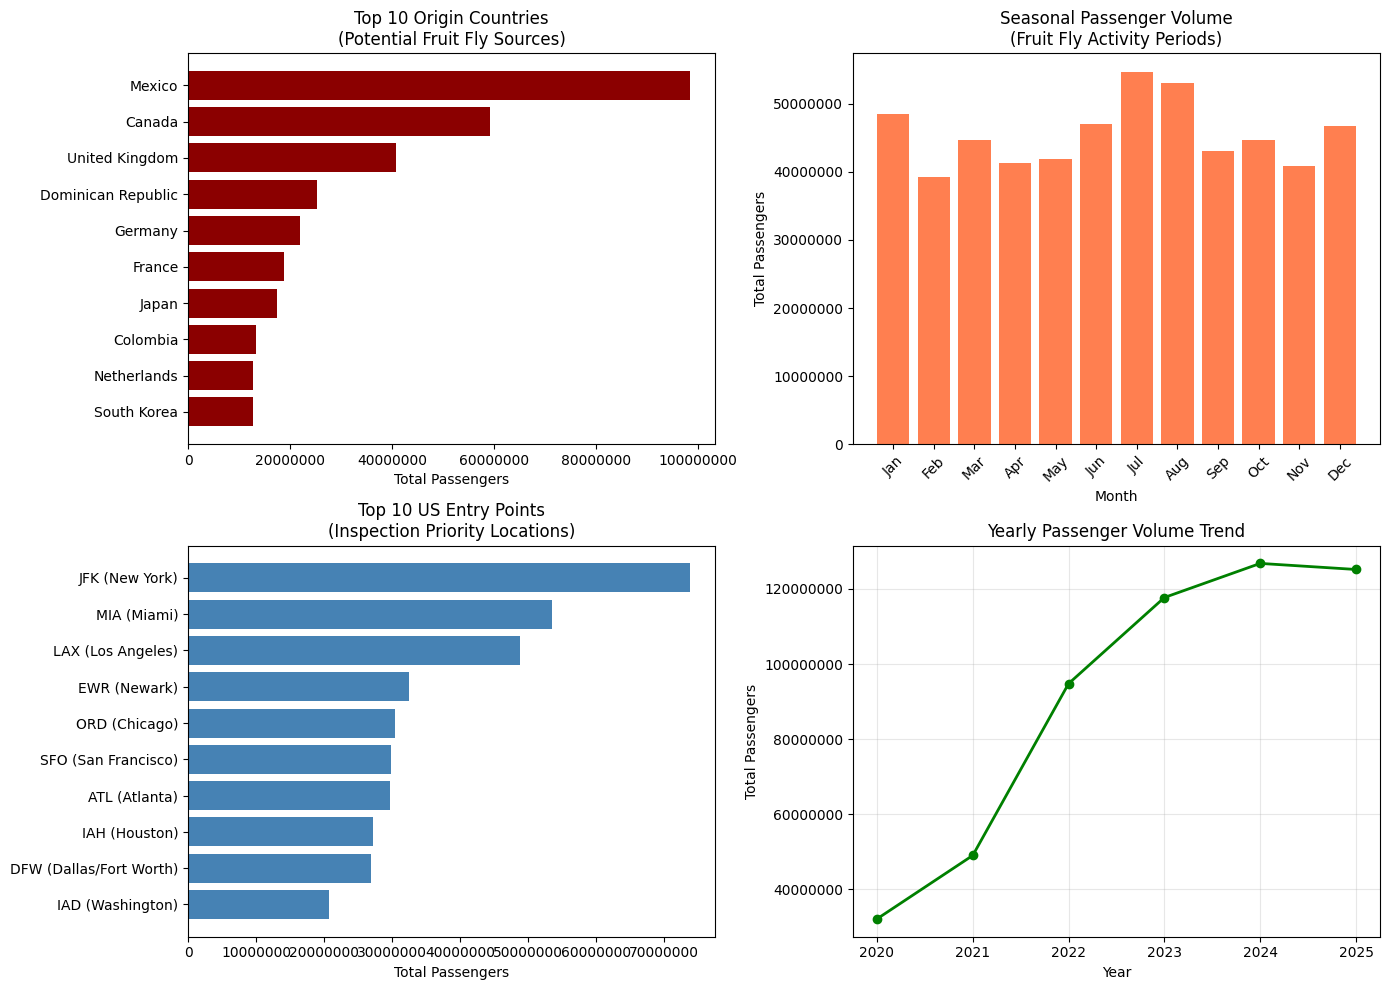

In [50]:
# ============================================================
# Visualization: International Pathways for Fruit Fly Risk
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top origin countries (risk sources)
top_countries = country_passengers.head(10)
axes[0,0].barh(top_countries.index[::-1], top_countries.values[::-1], color='darkred')
axes[0,0].set_xlabel('Total Passengers')
axes[0,0].set_title('Top 10 Origin Countries\n(Potential Fruit Fly Sources)')
axes[0,0].ticklabel_format(style='plain', axis='x')

# Monthly distribution (seasonal risk)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(monthly.index, monthly.values, color='coral')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Passengers')
axes[0,1].set_title('Seasonal Passenger Volume\n(Fruit Fly Activity Periods)')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(month_names, rotation=45)
axes[0,1].ticklabel_format(style='plain', axis='y')

# Top US entry points
top_entries = entry_points.head(10)
entry_labels = [f"{idx[0]} ({idx[1].split(',')[0]})" for idx in top_entries.index]
axes[1,0].barh(entry_labels[::-1], top_entries.values[::-1], color='steelblue')
axes[1,0].set_xlabel('Total Passengers')
axes[1,0].set_title('Top 10 US Entry Points\n(Inspection Priority Locations)')
axes[1,0].ticklabel_format(style='plain', axis='x')

# Yearly trend
yearly = ppq_GeoDataFrame.groupby('YEAR_WADS')['PASSENGERS'].sum().sort_index()
axes[1,1].plot(yearly.index, yearly.values, marker='o', linewidth=2, color='green')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Total Passengers')
axes[1,1].set_title('Yearly Passenger Volume Trend')
axes[1,1].ticklabel_format(style='plain', axis='y')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Fruit Fly Analysis

Expected Outcomes
• An interactive application/report to visualize the highest risk
pathways
• Monthly or weekly flow of passengers and/or cargo to different ports of
entry
• Analysis and visualizations to understand potential fruit fly
incursion
• What countries pose the highest risk at what time of the year?
• Ideas for optimizing monitoring foreign pathways in the U.S.

1. Create a solution using geospatial data, analysis, and visualizations to understand potential fruit fly
establishment from foreign pathways into the contiguous U.S., assisting program managers with data
driven decision making.
a. What foreign countries and their associated pathways pose the highest risk for fruit fly entry into
the U.S. and during what time of the year?
b. What indicators/variables would help predict where fruit flies would enter and establish in the
U.S?
2. Create an interactive application that assists managers to visualize the highest risk pathways at any
given time of the year and the monthly flow of passengers or cargo.
3. Any other ideas to contribute to optimizing fruit fly detection in the U.S. from foreign pathways

We will track four types of Exotic Fruit Flies: European Cherry Fruit Fly, Mediterrenean Fruit Fly, Mexican Fruit Fly and Oriental Fruit Fly


In [ ]:
fruitFlyDetections = gpd.read_file('../data/fruit_fly_detections.geojson')
fruitFlyDetections.head();



print("Names of fruit flies detected in the U.S.", fruitFlyDetections['CommonName'].unique())

print("The dataset provided does not show any sigtings for the European Cherry Fruit Fly so we will focus on the other three.")


selectedFruitFlies = fruitFlyDetections.loc[
    fruitFlyDetections['CommonName'].isin([
        'Mediterrenean Fruit Fly',
        'Mexican Fruit Fly',
        'Oriental Fruit Fly'
    ])
]


print(selectedFruitFlies.head())

print("Counties with detection of selected Fruit Flies: ", selectedFruitFlies.NAME.unique())


# Get the earliest and latest detection dates from the selectedFruitFlies DataFrame
# Assuming there is a column for detection date, e.g., 'DetectDate' or similar
# First, let's check the column names for the correct date column

print("Columns in selectedFruitFlies:", selectedFruitFlies.columns)

# Replace 'DetectDate' below with your actual date column if it's differently named

if 'monthyear' in selectedFruitFlies.columns:
    selectedFruitFlies['monthyear'] = pd.to_datetime(selectedFruitFlies['monthyear'], errors='coerce')
    earliest_date = selectedFruitFlies['monthyear'].min()
    latest_date = selectedFruitFlies['monthyear'].max()
    print(f"Earliest detection date: {earliest_date}")
    print(f"Latest detection date: {latest_date}")
else:
    print("No date column named 'monthyear'. Please update to use the actual date column name.")

Names of fruit flies detected in the U.S. <ArrowStringArray>
[      'Mexican Fruit Fly',         'Peach Fruit Fly',
         'Guava Fruit Fly',      'Oriental Fruit Fly',
 'Mediterranean Fruit Fly',         'Melon Fruit Fly',
     'Caribbean Fruit Fly',        'Sapote Fruit Fly',
          'Zeugodacus Tau',    'Queensland Fruit Fly']
Length: 10, dtype: str
The dataset provided does not show any sigtings for the European Cherry Fruit Fly so we will focus on the other three.
   OBJECTID            NAME STATE_NAME monthyear         CommonName  Count_  \
0         1  Cameron County      Texas   01/2025  Mexican Fruit Fly      13   
1         2  Cameron County      Texas   02/2022  Mexican Fruit Fly      10   
2         3  Cameron County      Texas   02/2024  Mexican Fruit Fly       2   
3         4  Cameron County      Texas   02/2025  Mexican Fruit Fly      14   
4         5  Cameron County      Texas   03/2022  Mexican Fruit Fly      14   

    Shape__Area  Shape__Length  \
0  2.439115e+

/var/folders/vg/xp5fys5x2jzg4w5vvxzkfm6m0000gn/T/ipykernel_32106/2463405586.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  selectedFruitFlies['monthyear'] = pd.to_datetime(selectedFruitFlies['monthyear'], errors='coerce')
